In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np

#9 scgpas is the highest among all

#Here initially before pd.to_numeric, errors='coerce' it was throwing an error but by using this function coerce we can avoid error as abc ,empty spaces or anyother mixed datatypes are converted as NAN.

# parental support 3 affecting cie marks in average i.e mean is calculated in the first step

#SInce my columns contain NAN so I must convert my NAN into  numeric only values.For cie marks we can remove hyphon and calculate the midpoints of the range

In [ ]:
# ==========================
import re
def to_num(val):
    if pd.isna(val):
        return np.nan
    
    s = str(val).lower().strip()

    # Remove quotes
    s = s.replace("'", "").replace('"', "")

    # Normalize all types of dashes
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")

    # Remove unwanted words
    s = s.replace("hr", "").replace("hrs", "").replace("hours", "")
    s = s.replace("to", "-")
    s = s.replace("%", "")
    s = s.replace(",", "")

    # Extract all numbers
    nums = re.findall(r"\d+(?:\.\d+)?", s)

    # Range → midpoint
    if len(nums) >= 2:
        return (float(nums[0]) + float(nums[1])) / 2
    
    # Single number
    if len(nums) == 1:
        return float(nums[0])
    
    return np.nan

# ==========================
# 3. Apply to mixed columns
# ==========================
mixed_cols = [
    "Attendance_Percentage",
    "Study_Hours_Per_Day",
    "CIE_Marks_50",
    "Sleep_Hours",
    "Screen_Time_Hours"
]

for col in mixed_cols:
    if col in df.columns:
        df[col] = df[col].apply(to_num)

# ==========================
# 4. Convert YES/NO/SOMETIMES etc.
# ==========================
event_map = {
    "yes": 1,
    "no": 0,
    "sometimes": 0.5,
    "rarely": 0.25,
    "often": 1
}

if "Participates_In_Events" in df.columns:
    df["Participates_In_Events"] = (
        df["Participates_In_Events"]
        .astype(str)
        .str.lower()
        .map(event_map)
    )

# ==========================
# 5. Force numeric for these
# ==========================
num_cols = ["Coding_Skill_5", "Parental_Support_5", "Motivation_5", "Current_SGPA"]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ==========================
# 6. Encode any leftover object columns
# ==========================
for col in df.select_dtypes(include="object").columns:
    df[col + "_cat"] = df[col].astype("category").cat.codes.replace({-1: np.nan})

# ==========================
# 7. Save cleaned dataset
# ==========================
df.to_excel("cleaned_output.xlsx", index=False)

print("Cleaning complete! Saved as cleaned_output.xlsx")

In [5]:
df = pd.read_excel("final_dataset_CLEANED_FULL.xlsx")
df.head()



,Column1,Branch,Semester,Attendance_Percentage,Study_Hours_Per_Day,CIE_Marks_50,Sleep_Hours,Screen_Time_Hours,Coding_Skill_5,Participates_In_Events,Parental_Support_5,Motivation_5,Current_SGPA,Branch_cat,Semester_cat
0,NaN,AIDS(cs ds),3rd,65.0,1.0,47.5,6.5,4.0,2.0,0.5,5.0,5.0,9.0,0,0
1,NaN,AIDS(cs ds),3rd,92.5,2.0,47.5,6.5,4.0,3.0,0.5,5.0,4.0,9.0,0,0
2,NaN,AIDS(cs ds),3rd,65.0,2.0,35.0,6.5,6.0,3.0,0.5,5.0,4.0,7.0,0,0
3,NaN,AIDS(cs ds),3rd,77.5,2.0,47.5,6.5,6.0,3.0,0.0,5.0,1.0,9.0,0,0
4,NaN,AIDS(cs ds),3rd,45.0,1.0,42.5,5.0,8.5,3.0,0.0,5.0,2.0,9.0,0,0


In [6]:
df = df.drop(index=22)
df = df.reset_index(drop=True)


In [7]:
df.to_excel("cleaned_output.xlsx", index=False)


In [8]:
# Remove the bad row where Branch == "Branch" or Semester == "Semester"
df = df[~((df["Branch"] == "Branch") & (df["Semester"] == "Semester"))]

# Reset the index
df = df.reset_index(drop=True)

# Save updated file
df.to_excel("final_dataset_CLEANED_FULL_no_badrow.xlsx", index=False)

print("Removed the unwanted row successfully!")


Removed the unwanted row successfully!


In [9]:
df = pd.read_excel("final_dataset_CLEANED_FULL_no_badrow.xlsx")
df.head()


,Column1,Branch,Semester,Attendance_Percentage,Study_Hours_Per_Day,CIE_Marks_50,Sleep_Hours,Screen_Time_Hours,Coding_Skill_5,Participates_In_Events,Parental_Support_5,Motivation_5,Current_SGPA,Branch_cat,Semester_cat
0,NaN,AIDS(cs ds),3rd,65.0,1,47.5,6.5,4.0,2,0.5,5,5,9.0,0,0
1,NaN,AIDS(cs ds),3rd,92.5,2,47.5,6.5,4.0,3,0.5,5,4,9.0,0,0
2,NaN,AIDS(cs ds),3rd,65.0,2,35.0,6.5,6.0,3,0.5,5,4,7.0,0,0
3,NaN,AIDS(cs ds),3rd,77.5,2,47.5,6.5,6.0,3,0.0,5,1,9.0,0,0
4,NaN,AIDS(cs ds),3rd,45.0,1,42.5,5.0,8.5,3,0.0,5,2,9.0,0,0


In [10]:
df.drop("Column1", axis=1, inplace=True)


In [11]:
print(df.head())


        Branch Semester  Attendance_Percentage  Study_Hours_Per_Day  \
0  AIDS(cs ds)      3rd                   65.0                    1   
1  AIDS(cs ds)      3rd                   92.5                    2   
2  AIDS(cs ds)      3rd                   65.0                    2   
3  AIDS(cs ds)      3rd                   77.5                    2   
4  AIDS(cs ds)      3rd                   45.0                    1   

   CIE_Marks_50  Sleep_Hours  Screen_Time_Hours  Coding_Skill_5  \
0          47.5          6.5                4.0               2   
1          47.5          6.5                4.0               3   
2          35.0          6.5                6.0               3   
3          47.5          6.5                6.0               3   
4          42.5          5.0                8.5               3   

   Participates_In_Events  Parental_Support_5  Motivation_5  Current_SGPA  \
0                     0.5                   5             5           9.0   
1               

In [12]:
cols = ["CIE_Marks_50", "Study_Hours_Per_Day", "Coding_Skill_5", "Motivation_5"]

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

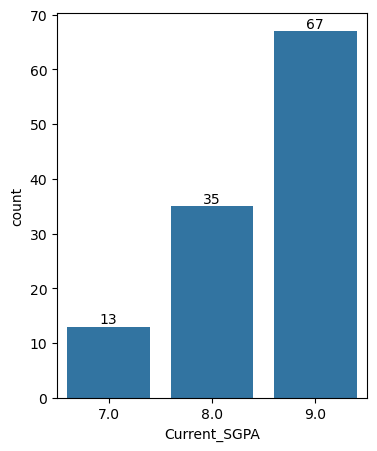

In [13]:
plt.figure(figsize=(4,5))
var=sns.countplot(data=df, x="Current_SGPA")
var.bar_label(var.containers[0])
plt.show()

In [14]:
gb=df.groupby("Parental_Support_5").agg({"CIE_Marks_50":'mean',"Study_Hours_Per_Day":'mean',"Coding_Skill_5":'mean',"Motivation_5":'mean'})
print(gb)

                    CIE_Marks_50  Study_Hours_Per_Day  Coding_Skill_5  \
Parental_Support_5                                                      
3                      43.088235             3.470588        3.705882   
4                      43.920455             3.090909        3.568182   
5                      42.669492             2.661017        3.389831   

                    Motivation_5  
Parental_Support_5                
3                       4.058824  
4                       4.068182  
5                       3.728814  


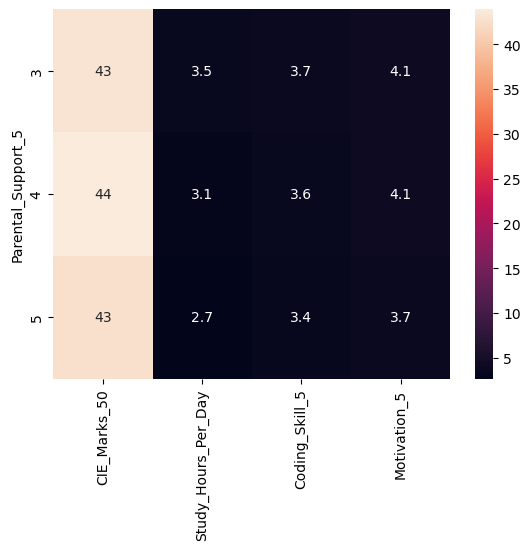

In [15]:
sns.heatmap(gb,annot=True)
plt.show()

In [16]:
gb1 = df.groupby("Study_Hours_Per_Day").agg({
    "CIE_Marks_50": 'mean',
    "Current_SGPA": 'mean',
    "Parental_Support_5": 'mean',
    "Branch_cat":'mean'
})
print(gb1)

                     CIE_Marks_50  Current_SGPA  Parental_Support_5  \
Study_Hours_Per_Day                                                   
1                       41.363636      8.600000            4.909091   
2                       40.000000      8.000000            4.517241   
3                       42.770270      8.400000            4.270270   
4                       46.162791      8.790698            4.162791   

                     Branch_cat  
Study_Hours_Per_Day              
1                      0.545455  
2                      3.034483  
3                      2.567568  
4                      1.906977  


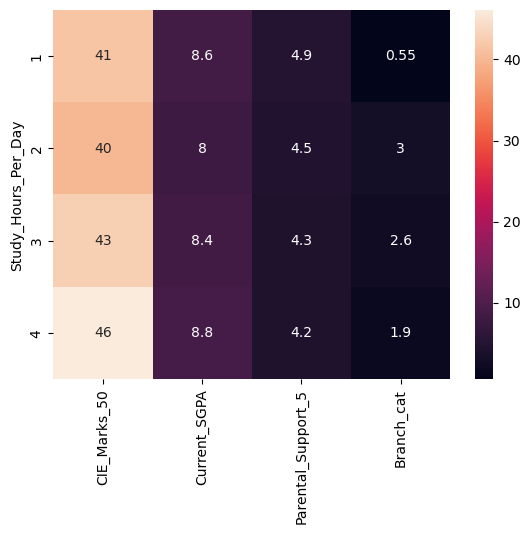

In [17]:
sns.heatmap(gb1,annot=True)
plt.show()

#from the above chart study hours have great impact on parental supp,cie marks and scgpa

In [18]:
gb2 = df.groupby("CIE_Marks_50").agg({
    "Study_Hours_Per_Day": "mean",
    "Current_SGPA": "mean",
    "Parental_Support_5": "mean",
    "Branch_cat": lambda x: x.mode()[0]
})

print(gb2)

              Study_Hours_Per_Day  Current_SGPA  Parental_Support_5  \
CIE_Marks_50                                                          
25.0                     2.333333      8.000000            4.333333   
35.0                     2.176471      7.235294            4.588235   
42.5                     2.823529      8.147059            4.235294   
47.5                     3.253968      8.984127            4.349206   

              Branch_cat  
CIE_Marks_50              
25.0                   5  
35.0                   4  
42.5                   0  
47.5                   0  


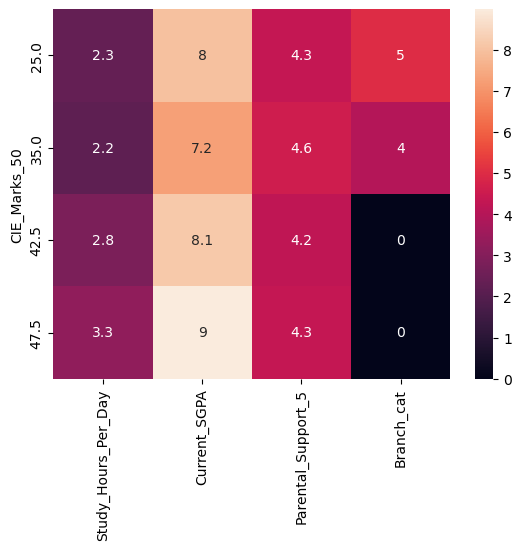

In [19]:
sns.heatmap(gb2,annot=True)
plt.show()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Branch                  120 non-null    object 
 1   Semester                120 non-null    object 
 2   Attendance_Percentage   120 non-null    float64
 3   Study_Hours_Per_Day     120 non-null    int64  
 4   CIE_Marks_50            120 non-null    float64
 5   Sleep_Hours             120 non-null    float64
 6   Screen_Time_Hours       120 non-null    float64
 7   Coding_Skill_5          120 non-null    int64  
 8   Participates_In_Events  120 non-null    float64
 9   Parental_Support_5      120 non-null    int64  
 10  Motivation_5            120 non-null    int64  
 11  Current_SGPA            115 non-null    float64
 12  Branch_cat              120 non-null    int64  
 13  Semester_cat            120 non-null    int64  
dtypes: float64(6), int64(6), object(2)
memory 

In [21]:
df.isna().sum()

Branch                    0
Semester                  0
Attendance_Percentage     0
Study_Hours_Per_Day       0
CIE_Marks_50              0
Sleep_Hours               0
Screen_Time_Hours         0
Coding_Skill_5            0
Participates_In_Events    0
Parental_Support_5        0
Motivation_5              0
Current_SGPA              5
Branch_cat                0
Semester_cat              0
dtype: int64

In [22]:
df["Current_SGPA"] = df["Current_SGPA"].fillna(df["Current_SGPA"].mean())


In [23]:
df.isna().sum()


Branch                    0
Semester                  0
Attendance_Percentage     0
Study_Hours_Per_Day       0
CIE_Marks_50              0
Sleep_Hours               0
Screen_Time_Hours         0
Coding_Skill_5            0
Participates_In_Events    0
Parental_Support_5        0
Motivation_5              0
Current_SGPA              0
Branch_cat                0
Semester_cat              0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(0)

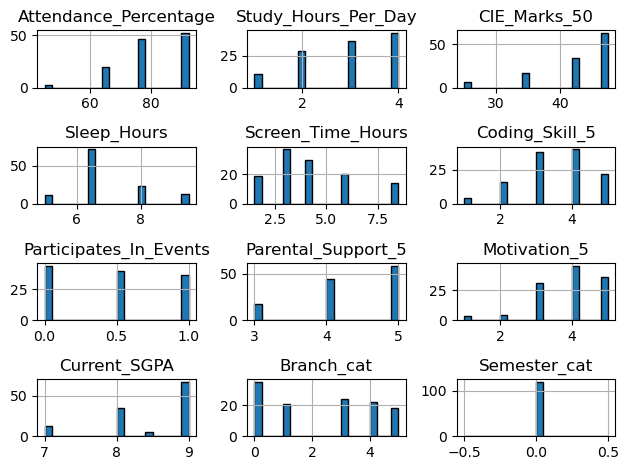

In [25]:
df.hist (bins=20, edgecolor="black")
plt.tight_layout()
plt.show()


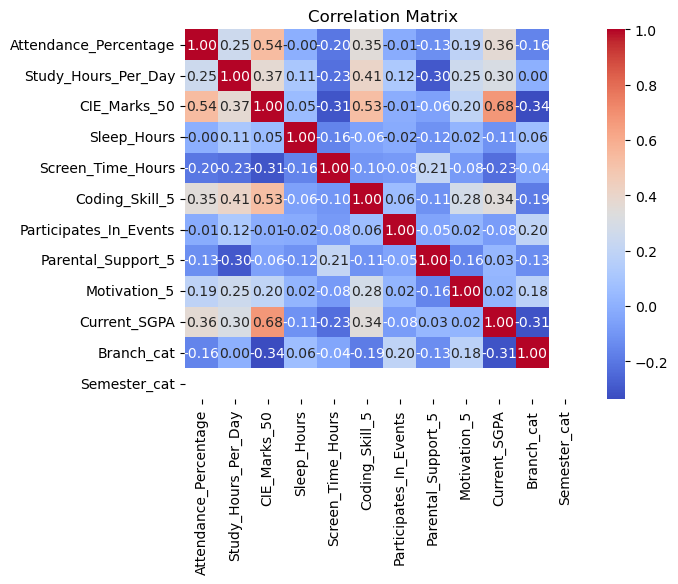

In [26]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [27]:
df.describe().columns

Index(['Attendance_Percentage', 'Study_Hours_Per_Day', 'CIE_Marks_50',
       'Sleep_Hours', 'Screen_Time_Hours', 'Coding_Skill_5',
       'Participates_In_Events', 'Parental_Support_5', 'Motivation_5',
       'Current_SGPA', 'Branch_cat', 'Semester_cat'],
      dtype='object')

In [28]:


features = [
    "Coding_Skill_5",
    "Attendance_Percentage",
    "Study_Hours_Per_Day",
    "CIE_Marks_50",
    "Sleep_Hours",
    "Participates_In_Events",
    "Parental_Support_5",
    "Branch_cat",
    "Motivation_5"
]





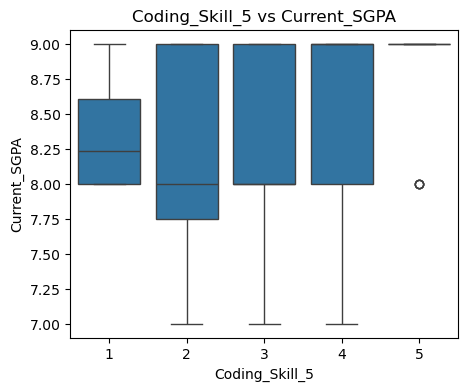

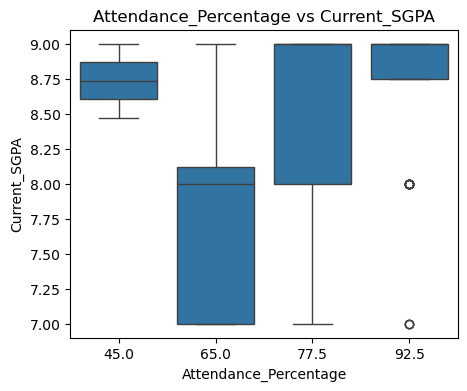

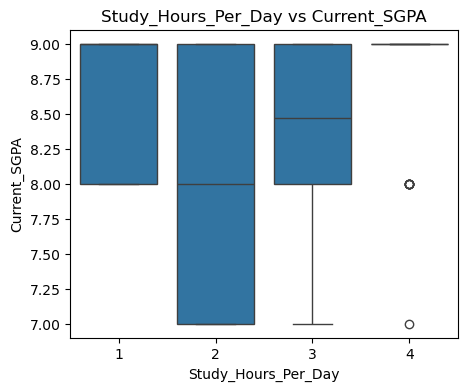

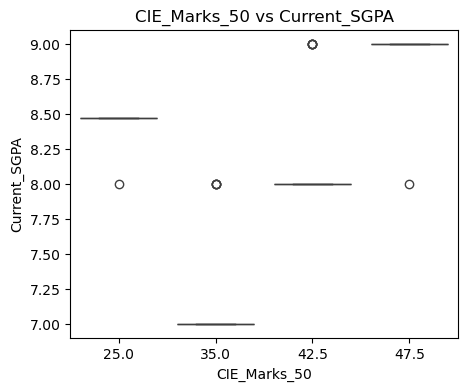

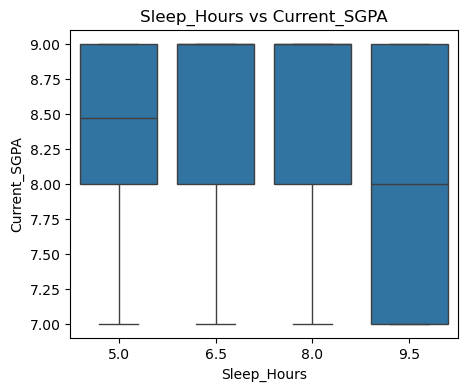

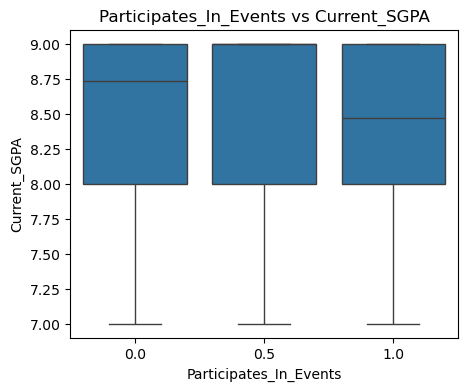

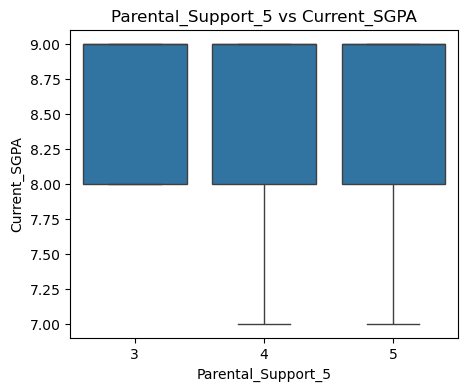

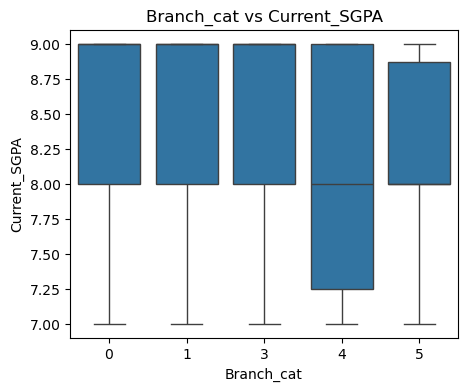

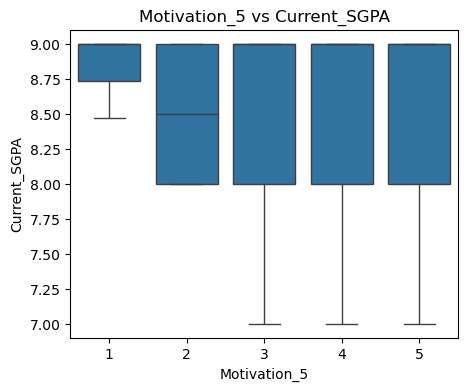

In [29]:
for col in features:
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df, x=col, y="Current_SGPA")
    plt.title(f"{col} vs Current_SGPA")
    plt.show()


In [30]:
df['Attendance_Percentage'].value_counts()


Attendance_Percentage
92.5    52
77.5    46
65.0    20
45.0     2
Name: count, dtype: int64

In [31]:
df['Coding_Skill_5'].value_counts()

Coding_Skill_5
4    40
3    38
5    22
2    16
1     4
Name: count, dtype: int64

In [32]:
df.describe().columns


Index(['Attendance_Percentage', 'Study_Hours_Per_Day', 'CIE_Marks_50',
       'Sleep_Hours', 'Screen_Time_Hours', 'Coding_Skill_5',
       'Participates_In_Events', 'Parental_Support_5', 'Motivation_5',
       'Current_SGPA', 'Branch_cat', 'Semester_cat'],
      dtype='object')

In [33]:
df.to_excel("Data_Preprocessing.xlsx",index=False)

In [34]:
df=pd.read_excel("Data_Preprocessing.xlsx")

In [35]:
print(df.head())


        Branch Semester  Attendance_Percentage  Study_Hours_Per_Day  \
0  AIDS(cs ds)      3rd                   65.0                    1   
1  AIDS(cs ds)      3rd                   92.5                    2   
2  AIDS(cs ds)      3rd                   65.0                    2   
3  AIDS(cs ds)      3rd                   77.5                    2   
4  AIDS(cs ds)      3rd                   45.0                    1   

   CIE_Marks_50  Sleep_Hours  Screen_Time_Hours  Coding_Skill_5  \
0          47.5          6.5                4.0               2   
1          47.5          6.5                4.0               3   
2          35.0          6.5                6.0               3   
3          47.5          6.5                6.0               3   
4          42.5          5.0                8.5               3   

   Participates_In_Events  Parental_Support_5  Motivation_5  Current_SGPA  \
0                     0.5                   5             5           9.0   
1               

In [36]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error,r2_score
from sklearn. linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor 
from sklearn.tree import DecisionTreeRegressor

In [37]:
df.columns


Index(['Branch', 'Semester', 'Attendance_Percentage', 'Study_Hours_Per_Day',
       'CIE_Marks_50', 'Sleep_Hours', 'Screen_Time_Hours', 'Coding_Skill_5',
       'Participates_In_Events', 'Parental_Support_5', 'Motivation_5',
       'Current_SGPA', 'Branch_cat', 'Semester_cat'],
      dtype='object')

In [38]:

feature_for_model = [
    "Coding_Skill_5",
    "Attendance_Percentage",
    "Study_Hours_Per_Day",
    "CIE_Marks_50",
    "Motivation_5"
]


In [39]:
target="Current_SGPA"

In [40]:

df_model = df [feature_for_model+ [target]].copy()

In [41]:
df_model

,Coding_Skill_5,Attendance_Percentage,Study_Hours_Per_Day,CIE_Marks_50,Motivation_5,Current_SGPA
0,2,65.0,1,47.5,5,9.0
1,3,92.5,2,47.5,4,9.0
2,3,65.0,2,35.0,4,7.0
3,3,77.5,2,47.5,1,9.0
4,3,45.0,1,42.5,2,9.0
...,...,...,...,...,...,...
115,4,77.5,4,47.5,5,9.0
116,5,77.5,4,47.5,4,9.0
117,4,92.5,4,47.5,5,9.0
118,5,92.5,4,47.5,5,9.0


In [42]:
from sklearn.neighbors import KNeighborsRegressor

models = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },

    "RidgeRegression": {
        "model": Ridge(),
        "params": {
            "alpha": [0.1, 1.0, 10]
        }
    },

    "DecisionTree": {
        "model": DecisionTreeRegressor(),
        "params": {
            "max_depth": [2, 3, 4],
            "min_samples_split": [2, 4, 6]
        }
    },

    "RandomForest": {
        "model": RandomForestRegressor(),
        "params": {
            "n_estimators": [20, 50],
            "max_depth": [3, 4],
            "min_samples_split": [2, 4]
        }
    },

    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            "n_neighbors": [2, 3, 4, 5],
            "weights": ["uniform", "distance"]
        }
    }
}


In [43]:
x=df_model[feature_for_model]
y=df_model[target]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42)
len (y_test)


24

In [44]:
len(y_train)

96

In [45]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [46]:
best_models=[]

In [47]:
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.pipeline import Pipeline
for name, cfg in models.items():
    print(f"Training {name}...")

    pipe = Pipeline([
        ("scaler", scaler),
        ("model", cfg["model"])
    ])

Training LinearRegression...
Training RidgeRegression...
Training DecisionTree...
Training RandomForest...
Training KNN...


In [48]:
params = {}
for p_name, p_values in cfg["params"].items():
     params[f"model__{p_name}"] = p_values

In [49]:
grid = GridSearchCV(pipe, params, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)

# fit
grid.fit(X_train, y_train)

# predict on test set using best estimator
y_pred = grid.predict(X_test)

    # metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

best_models.append({
    "model": name,
    "best_params": grid.best_params_,
    "rmse": rmse,
    "r2": r2,
    "best_estimator": grid.best_estimator_
})

# convert results to DataFrame for easy viewing
results_df = pd.DataFrame([{
    "model": m["model"],
    "best_params": m["best_params"],
    "rmse": m["rmse"],
    "r2": m["r2"]
} for m in best_models]).sort_values("rmse")


In [50]:
print("\nResults (sorted by RMSE):")
print(results_df.to_string(index=False))


Results (sorted by RMSE):
model                                            best_params     rmse       r2
  KNN {'model__n_neighbors': 4, 'model__weights': 'uniform'} 0.481426 0.597892


In [51]:
best_overall = min(best_models, key=lambda x: x["rmse"])
print(f"\nBest overall model: {best_overall['model']} with RMSE={best_overall['rmse']:.4f} and R2={best_overall['r2']:.4f}")


Best overall model: KNN with RMSE=0.4814 and R2=0.5979


In [52]:
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same parameters
X_test_scaled = scaler.transform(X_test)

In [53]:
pd.DataFrame(X_train_scaled, columns=X_train.columns).head()


,Coding_Skill_5,Attendance_Percentage,Study_Hours_Per_Day,CIE_Marks_50,Motivation_5
0,0.392799,0.942864,1.015776,0.716524,-0.891400
1,0.392799,-0.435536,-0.994833,-1.271519,0.127343
2,-1.446650,0.942864,-2.000137,-0.078693,-1.910144
3,-0.526925,0.942864,0.010472,-1.271519,-0.891400
4,1.312523,0.942864,1.015776,0.716524,1.146086


In [54]:

from sklearn.neighbors import KNeighborsRegressor  
from sklearn.metrics import mean_squared_error 

scores = []  

for i in range(1, 16):
    knn = KNeighborsRegressor(n_neighbors=i)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # Calculate RMSE manually using numpy
    r2 = r2_score(y_test, y_pred)

    print(f"K={i} → MSE={mse:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

K=1 → MSE=0.0534, RMSE=0.2311, R²=0.9074
K=2 → MSE=0.0342, RMSE=0.1849, R²=0.9407
K=3 → MSE=0.0433, RMSE=0.2080, R²=0.9250
K=4 → MSE=0.0583, RMSE=0.2415, R²=0.8988
K=5 → MSE=0.0724, RMSE=0.2691, R²=0.8743
K=6 → MSE=0.0932, RMSE=0.3053, R²=0.8383
K=7 → MSE=0.1178, RMSE=0.3433, R²=0.7955
K=8 → MSE=0.1417, RMSE=0.3765, R²=0.7541
K=9 → MSE=0.1738, RMSE=0.4169, R²=0.6985
K=10 → MSE=0.2025, RMSE=0.4500, R²=0.6487
K=11 → MSE=0.2225, RMSE=0.4717, R²=0.6140
K=12 → MSE=0.2352, RMSE=0.4850, R²=0.5919
K=13 → MSE=0.2402, RMSE=0.4901, R²=0.5833
K=14 → MSE=0.2395, RMSE=0.4894, R²=0.5844
K=15 → MSE=0.2561, RMSE=0.5061, R²=0.5556


#training 80% datas on 15 different k values and checking their rmse,mseand r2 to find the best k value for my model 

In [55]:
best_knn = KNeighborsRegressor(n_neighbors=2)
best_knn.fit(X_train, y_train)


KNeighborsRegressor(n_neighbors=2)

In [56]:
# 1. Create a sample with the correct number of features (5 instead of 12)
test_sample = [[
    2, 20, 4, 20, 1 # Only include 5 features to match what scaler expects
]]

# 2. Scale it
test_sample_scaled = scaler.transform(test_sample)

# 3. Predict
prediction = best_knn.predict(test_sample_scaled)
print("Predicted SGPA:", prediction[0])

Predicted SGPA: 8.469565217391304


C:\Users\Nitro\anaconda3\ANACONDA\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Nitro\anaconda3\ANACONDA\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


In [57]:
test_sample = [[4, 20, 4, 20, 1]]   # change values to test different cases
print("raw:", test_sample)

# scale and print
test_sample_scaled = scaler.transform(test_sample)
print("scaled:", test_sample_scaled)


raw: [[4, 20, 4, 20, 1]]
scaled: [[ 0.39279888 -5.71940577  1.01577642 -3.65716917 -2.92888688]]


C:\Users\Nitro\anaconda3\ANACONDA\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [58]:
import numpy as np
print("Mean SGPA:", np.mean(y_train))
print("Std SGPA:", np.std(y_train))
print("Unique counts (top):", np.unique(y_train, return_counts=True))


Mean SGPA: 8.482789855072463
Std SGPA: 0.6513303471507468
Unique counts (top): (array([7.        , 8.        , 8.46956522, 9.        ]), array([ 9, 29,  5, 53]))


In [59]:
# use the same test_sample you used previously
df_test = pd.DataFrame(test_sample, columns=X_train.columns)   # ensures correct order/names
test_scaled = scaler.transform(df_test)

distances, indices = best_knn.kneighbors(test_scaled, n_neighbors=2)
print("Indices:", indices)
print("Distances:", distances)
print("Neighbor targets:", y_train.iloc[indices[0]].values)


Indices: [[28 55]]
Distances: [[58.3908945  76.58580541]]
Neighbor targets: [8.46956522 8.46956522]


C:\Users\Nitro\anaconda3\ANACONDA\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


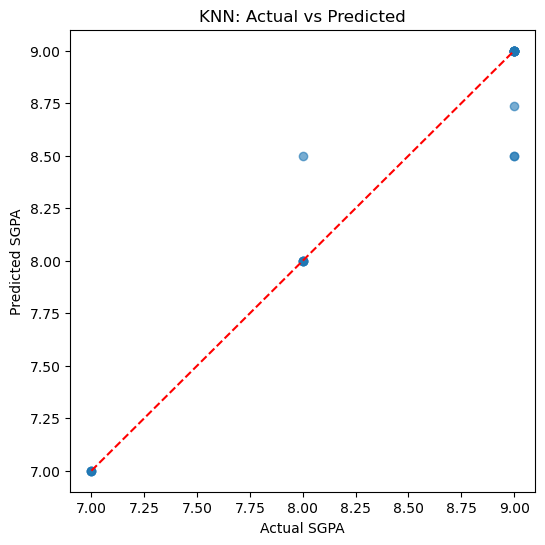

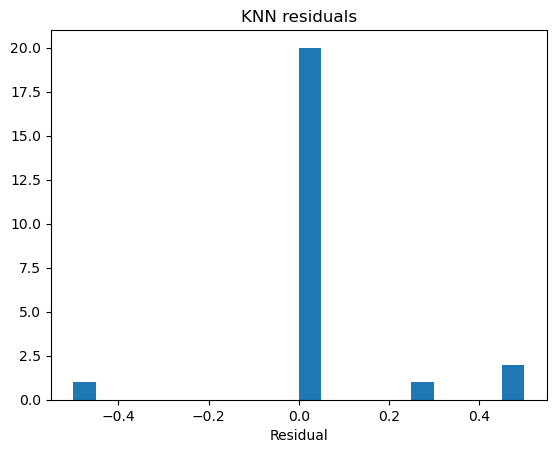

In [60]:
import matplotlib.pyplot as plt

# for best_knn
y_pred_knn = best_knn.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_knn, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual SGPA"); plt.ylabel("Predicted SGPA"); plt.title("KNN: Actual vs Predicted")
plt.show()

# residual histogram
resid = y_test - y_pred_knn
plt.hist(resid, bins=20);
plt.title("KNN residuals"); plt.xlabel("Residual"); plt.show()


CIE_Marks_50             0.823031
Study_Hours_Per_Day      0.065769
Coding_Skill_5           0.056978
Motivation_5             0.043237
Attendance_Percentage    0.010984
dtype: float64


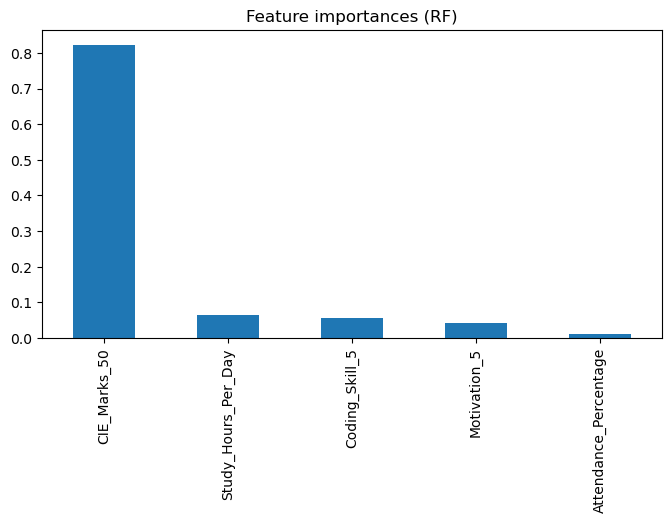

In [61]:
# Import necessary libraries
import pandas as pd
from sklearn.ensemble import RandomForestRegressor  # Changed to Regressor for continuous target values
import matplotlib.pyplot as plt

# Assuming X_train and y_train are already defined
# First, create and train the Random Forest model
rf = RandomForestRegressor()  # Changed to RandomForestRegressor for regression tasks
rf.fit(X_train, y_train)  # Train the model

# Now extract and visualize feature importances
feat_imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(feat_imp)
feat_imp.plot.bar(figsize=(8,4))
plt.title("Feature importances (RF)")
plt.show()

#pickle is used to save and load  projects done in notebook

In [62]:
# 1. Verify the trained model exists
print("knn_model exists?", 'knn_model' in globals())
try:
    print("has predict:", hasattr(knn_model, "predict"))
except NameError:
    raise RuntimeError("knn_model not found. Run the training cell first.")

# 2. Save with joblib (recommended for sklearn)
import joblib
# Save into the backend folder your FastAPI expects (adjust path if needed)
joblib.dump(knn_model, "../backend/model/knn_model.pkl")
print("Saved knn_model to ../backend/model/knn_model.pkl")

# 3. Quick sanity-check load and predict
m = joblib.load("../backend/model/knn_model.pkl")
import numpy as np
print("loaded type:", type(m), "has_predict:", hasattr(m, "predict"))
# Quick sample (use correct feature order/scale)
sample = np.array([4, 85, 3, 40, 5]).reshape(1, -1)
print("sample predict:", m.predict(sample))


knn_model exists? False


RuntimeError: knn_model not found. Run the training cell first.

In [63]:
# Step 1: Check if your trained model exists (replace 'best_knn' with your actual variable name if different)
try:
    print("Model found:", type(best_knn))
    print("Has predict method:", hasattr(best_knn, "predict"))
except NameError:
    print("ERROR: 'best_knn' not found. Make sure you've run the training cell and the variable is named correctly.")
    # List all variables in namespace to help debug
    import sys
    print("Available variables:", [name for name in dir() if not name.startswith('_')])

# Step 2: Save model using joblib (recommended for sklearn models, more efficient than pickle)
import joblib
model_filename = "best_knn_model.joblib"  # .joblib extension is standard for sklearn
joblib.dump(best_knn, model_filename)
print(f"✅ Model saved successfully as '{model_filename}'")

# Step 3: Verify save worked by loading it back (optional but recommended)
loaded_model = joblib.load(model_filename)
print("✅ Model loaded successfully!")
print("Model type:", type(loaded_model))
print("Predict method available:", hasattr(loaded_model, "predict"))

# Alternative: Save as .pkl format (if you specifically need pickle format)
import pickle
pkl_filename = "best_knn_model.pkl"
with open(pkl_filename, 'wb') as f:
    pickle.dump(best_knn, f)
print(f"✅ Model also saved as pickle: '{pkl_filename}'")


Model found: <class 'sklearn.neighbors._regression.KNeighborsRegressor'>
Has predict method: True
✅ Model saved successfully as 'best_knn_model.joblib'
✅ Model loaded successfully!
Model type: <class 'sklearn.neighbors._regression.KNeighborsRegressor'>
Predict method available: True
✅ Model also saved as pickle: 'best_knn_model.pkl'
